# 基于时空特征与XGBoost的城市路段旅行时间预测
---
**技术栈**: DuckDB → Polars → XGBoost / RandomForest → SHAP → 可视化  
**数据**: 贵阳132条路段旅行时间（2016-2017年），~2600万条记录  
**目标**: 基于历史时空特征预测未来2分钟时间片的平均旅行时间

## 0. 环境配置与全局参数

In [1]:
from __future__ import annotations
import os, sys, warnings
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple

import numpy as np
import polars as pl
import duckdb
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import shap

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
%matplotlib inline

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# ====== 全局配置 ======
TEST_MODE = True           # True=快速验证(1000行), False=全量运行
TEST_NROWS = 1000

BASE_DIR = Path(r'C:\Users\苏菡\Desktop\智慧交通预测')
OUTPUT_DIR = BASE_DIR / 'processed'
FIGURE_DIR = BASE_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

STATIC_INFO_FILE = BASE_DIR / 'gy_link_info.txt'
TOPOLOGY_FILE   = BASE_DIR / 'gy_link_top.txt'
TRAVEL_TIME_FILES = {
    'part1': BASE_DIR / 'gy_link_travel_time_part1.txt',
    'part2': BASE_DIR / 'gy_link_travel_time_part2.txt',
    'part3': BASE_DIR / 'gy_link_travel_time_part3.txt',
}

XGB_PARAMS = dict(n_estimators=100, max_depth=6, learning_rate=0.1,
                 subsample=0.8, colsample_bytree=0.8,
                 random_state=42, n_jobs=-1)

def print_progress(msg: str):
    ts = datetime.now().strftime('%H:%M:%S')
    print(f'[{ts}] {msg}')

print(f'TEST_MODE={TEST_MODE} | 数据目录: {BASE_DIR}')

TEST_MODE=True | 数据目录: C:\Users\苏菡\Desktop\智慧交通预测


## 1. 加载静态数据（路段信息 + 拓扑关系）

In [3]:
def load_static_data() -> Tuple[pl.DataFrame, pl.DataFrame]:
    """加载路段静态信息 (length/lane_num/link_class) 和拓扑关系 (in_links/out_links)"""
    static = pl.read_csv(
        STATIC_INFO_FILE, separator=';',
        schema_overrides={
            'link_ID': pl.Utf8,       # 19位ID超i64范围
            'length': pl.Float64,
            'width': pl.Float64,
            'link_class': pl.Int32,
        },
    )
    static = static.rename({'link_ID': 'link_id', 'width': 'lane_num'})

    topo = pl.read_csv(
        TOPOLOGY_FILE, separator=';',
        schema_overrides={'link_ID': pl.Utf8, 'in_links': pl.Utf8, 'out_links': pl.Utf8},
    )
    topo = topo.rename({'link_ID': 'link_id'})

    print_progress(f'静态表: {static.shape}  拓扑表: {topo.shape}')
    return static, topo

static_df, topo_df = load_static_data()
display(static_df.head(3))
display(topo_df.head(3))

[16:00:37] 静态表: (132, 4)  拓扑表: (132, 3)


link_id,length,lane_num,link_class
str,f64,f64,i32
"""4377906289869500514""",57.0,3.0,1
"""4377906284594800514""",247.0,9.0,1
"""4377906289425800514""",194.0,3.0,1


link_id,in_links,out_links
str,str,str
"""4377906289869500514""","""4377906285525800514""","""4377906281969500514"""
"""4377906284594800514""","""4377906284514600514""","""4377906285594800514"""
"""4377906289425800514""",null,"""4377906284653600514"""


## 2. DuckDB 加载旅行时间数据（三文件合并）

使用 DuckDB 读取三份原始 CSV（合计~26M行），强制 link_ID 为 VARCHAR 保留精度。
Part2 列名为 `linkID`（无下划线），其他为 `link_ID`，需分别指定。

In [4]:
def load_travel_time(file_path: Path, col_link: str = 'link_ID',
                     test_nrows: int | None = None) -> pl.DataFrame:
    """DuckDB 读取 CSV → 解析 time_interval → 返回 Polars DataFrame"""
    con = duckdb.connect(':memory:')
    limit_clause = f'LIMIT {test_nrows}' if test_nrows else ''
    fp = file_path.as_posix()
    sql = (
        'WITH raw AS ( '
        "  SELECT * FROM read_csv('" + fp + "', sep=';', header=true, "
        "    columns={'" + col_link + "': 'VARCHAR', 'date': 'VARCHAR', "
        "             'time_interval': 'VARCHAR', 'travel_time': 'DOUBLE'}) "
        ') '
        'SELECT '
        '  "' + col_link + '" AS link_id, '
        '  CAST("date" AS DATE) AS date, '
        '  CAST(str_split(str_split("time_interval", \'[\')[2], \',\')[1] AS TIMESTAMP) AS time_start, '
        '  CAST(trim(str_split(str_split("time_interval", \')\')[1], \',\')[2], \' \') AS TIMESTAMP) AS time_end, '
        '  "travel_time" '
        'FROM raw '
        'WHERE "travel_time" IS NOT NULL '
        '  AND "time_interval" IS NOT NULL '
        + limit_clause
    )
    df = con.execute(sql).pl()
    con.close()
    print_progress(f'加载 {file_path.name}: {df.shape[0]:,} 行')
    return df

# 测试模式每文件仅读1000行
nrows = TEST_NROWS if TEST_MODE else None
tt_p1 = load_travel_time(TRAVEL_TIME_FILES['part1'], col_link='link_ID', test_nrows=nrows)
tt_p2 = load_travel_time(TRAVEL_TIME_FILES['part2'], col_link='linkID', test_nrows=nrows)
tt_p3 = load_travel_time(TRAVEL_TIME_FILES['part3'], col_link='link_ID', test_nrows=nrows)

# 合并三份数据
tt_all = pl.concat([tt_p1, tt_p2, tt_p3], how='vertical')
print_progress(f'合并: {tt_all.shape[0]:,} 行 ({tt_p1.shape[0]:,}+{tt_p2.shape[0]:,}+{tt_p3.shape[0]:,})')
print(f'日期范围: {tt_all["date"].min()} ~ {tt_all["date"].max()}')
print(f'路段数: {tt_all["link_id"].n_unique()}')
tt_all.head(5)

[16:00:38] 加载 gy_link_travel_time_part1.txt: 1,000 行


[16:00:38] 加载 gy_link_travel_time_part2.txt: 1,000 行


[16:00:38] 加载 gy_link_travel_time_part3.txt: 1,000 行
[16:00:38] 合并: 3,000 行 (1,000+1,000+1,000)
日期范围: 2016-05-21 ~ 2017-05-06
路段数: 131


link_id,date,time_start,time_end,travel_time
str,date,datetime[μs],datetime[μs],f64
"""9377906285566510514""",2016-05-21,2016-05-21 23:20:00,2016-05-21 23:22:00,17.6
"""3377906288228510514""",2016-05-21,2016-05-21 18:46:00,2016-05-21 18:48:00,3.5
"""3377906284395510514""",2016-05-21,2016-05-21 07:06:00,2016-05-21 07:08:00,10.0
"""4377906284959500514""",2016-05-21,2016-05-21 14:34:00,2016-05-21 14:36:00,3.5
"""9377906282776510514""",2016-05-21,2016-05-21 05:04:00,2016-05-21 05:06:00,1.5


## 3. 特征工程 (Polars)

构建4类特征：
- **时间特征**: hour, minute, day_of_week, is_morning_peak, is_evening_peak
- **滞后特征**: lag1, lag2, lag4（按link分组、时间排序）
- **空间特征**: 上游link同一时间片的travel_time
- **静态特征**: link_class one-hot, length, lane_num

目标变量: 下一个时间片的travel_time

In [5]:
def engineer_features(df: pl.DataFrame, static_df: pl.DataFrame,
                      topo_df: pl.DataFrame) -> pl.DataFrame:
    """从原始旅行时间数据构建时空特征矩阵"""
    n_before = df.shape[0]

    # 3a. 时间特征
    df = df.with_columns([
        pl.col('time_start').dt.hour().alias('hour'),
        pl.col('time_start').dt.minute().alias('minute'),
        pl.col('time_start').dt.weekday().alias('day_of_week'),
    ])
    df = df.with_columns([
        ((pl.col('hour') >= 6) & (pl.col('hour') < 9)).cast(pl.Int32).alias('is_morning_peak'),
        ((pl.col('hour') >= 17) & (pl.col('hour') < 19)).cast(pl.Int32).alias('is_evening_peak'),
    ])

    # 3b. 滞后特征
    df = df.sort(['link_id', 'time_start'])
    df = df.with_columns([
        pl.col('travel_time').shift(1).over('link_id').alias('lag1'),
        pl.col('travel_time').shift(2).over('link_id').alias('lag2'),
        pl.col('travel_time').shift(4).over('link_id').alias('lag4'),
    ])

    # 3c. 空间特征（上游link同一时间片）
    upstream_map = topo_df.select([
        pl.col('link_id'),
        pl.col('in_links').str.split(',').list.first().alias('upstream_link_id'),
    ]).filter(pl.col('upstream_link_id').is_not_null())

    upstream_tt = df.select([
        pl.col('link_id').alias('upstream_link_id'),
        pl.col('time_start'),
        pl.col('travel_time').alias('upstream_travel_time'),
    ])

    df = df.join(upstream_map, on='link_id', how='left')
    df = df.join(upstream_tt, on=['upstream_link_id', 'time_start'], how='left')
    df = df.with_columns(pl.col('upstream_travel_time').fill_null(-1.0))

    # 3d. 静态特征
    static_sel = static_df.select(['link_id', 'length', 'lane_num', 'link_class'])
    df = df.join(static_sel, on='link_id', how='left')
    df = df.with_columns([
        pl.col('length').fill_null(pl.col('length').mean()),
        pl.col('lane_num').fill_null(pl.col('lane_num').mean()),
        pl.col('link_class').fill_null(-1).cast(pl.Int32),
    ])

    # link_class one-hot
    dummies = df.select('link_class').to_dummies('link_class')
    dummies = dummies.rename({c: f'link_class_{c.replace("link_class_","")}' for c in dummies.columns})
    df = pl.concat([df, dummies], how='horizontal')

    # 3e. 目标变量
    df = df.with_columns(pl.col('travel_time').shift(-1).over('link_id').alias('target'))

    # 3f. 清理
    df = df.drop_nulls(subset=['target', 'lag1', 'lag2', 'lag4'])

    n_after = df.shape[0]
    print_progress(f'特征工程: {n_before:,} -> {n_after:,} rows (removed {n_before-n_after:,})')
    print(f'特征列数: {df.shape[1]}')
    return df

df = engineer_features(tt_all, static_df, topo_df)
df.head(5)

[16:00:38] 特征工程: 3,000 -> 2,373 rows (removed 627)
特征列数: 20


link_id,date,time_start,time_end,travel_time,hour,minute,day_of_week,is_morning_peak,is_evening_peak,lag1,lag2,lag4,upstream_link_id,upstream_travel_time,length,lane_num,link_class,link_class_1,target
str,date,datetime[μs],datetime[μs],f64,i8,i8,i8,i32,i32,f64,f64,f64,str,f64,f64,f64,i32,u8,f64
"""3377906280028510514""",2016-05-21,2016-05-21 13:36:00,2016-05-21 13:38:00,6.3,13,36,6,0,0,10.2,4.6,8.0,"""4377906282541600514""",-1.0,48.0,3.0,1,1,10.9
"""3377906280028510514""",2016-05-21,2016-05-21 15:26:00,2016-05-21 15:28:00,10.9,15,26,6,0,0,6.3,10.2,4.2,"""4377906282541600514""",100.2,48.0,3.0,1,1,7.5
"""3377906280028510514""",2016-05-21,2016-05-21 16:32:00,2016-05-21 16:34:00,7.5,16,32,6,0,0,10.9,6.3,4.6,"""4377906282541600514""",-1.0,48.0,3.0,1,1,6.7
"""3377906280028510514""",2016-05-21,2016-05-21 17:02:00,2016-05-21 17:04:00,6.7,17,2,6,0,1,7.5,10.9,10.2,"""4377906282541600514""",-1.0,48.0,3.0,1,1,5.4
"""3377906280028510514""",2016-05-21,2016-05-21 23:10:00,2016-05-21 23:12:00,5.4,23,10,6,0,0,6.7,7.5,6.3,"""4377906282541600514""",-1.0,48.0,3.0,1,1,5.2


## 3.5 保存为 Parquet（按日期分区）

In [6]:
def save_as_parquet(df: pl.DataFrame, output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    dates = df['date'].unique().sort().to_list()
    for d in dates:
        partition = df.filter(pl.col('date') == d)
        fname = output_dir / f'date={d}' / 'data.parquet'
        fname.parent.mkdir(parents=True, exist_ok=True)
        partition.write_parquet(fname)
    df.write_parquet(output_dir / 'all_features.parquet')
    print_progress(f'Parquet 已保存: {output_dir} ({len(dates)} 个日期分区)')

save_as_parquet(df, OUTPUT_DIR)

[16:00:38] Parquet 已保存: C:\Users\苏菡\Desktop\智慧交通预测\processed (2 个日期分区)


## 4. 训练集/验证集划分

**全量模式**：2016-03 ~ 2017-05 全天 = 训练集，2017-06 第一周 [8:00-9:00) = 验证集  
**测试模式**：因数据量不足以切分，自动回退到时序 80/20

In [7]:
def split_train_val(df: pl.DataFrame, train_end='2017-05-31',
                    val_start='2017-06-01', val_end='2017-06-07', hour_range=(8, 9)):
    exclude = {'link_id', 'travel_time', 'target', 'time_start', 'time_end',
               'date', 'upstream_link_id', 'link_class'}
    feature_cols = [c for c in df.columns if c not in exclude]

    train_df = df.filter(
        (pl.col('date') >= pl.lit('2016-03-01').cast(pl.Date))
        & (pl.col('date') <= pl.lit(train_end).cast(pl.Date))
    )
    val_df = df.filter(
        (pl.col('date') >= pl.lit(val_start).cast(pl.Date))
        & (pl.col('date') <= pl.lit(val_end).cast(pl.Date))
        & (pl.col('hour') >= hour_range[0])
        & (pl.col('hour') < hour_range[1])
    )

    if train_df.shape[0] < 50 or val_df.shape[0] < 20:
        print_progress('Not enough data for date split, fallback to time series 80/20')
        n = df.shape[0]
        df_sorted = df.sort('time_start')
        train_df = df_sorted[:int(n * 0.8)]
        val_df = df_sorted[int(n * 0.8):]

    X_train = train_df.select(feature_cols).to_numpy()
    y_train = train_df.select('target').to_numpy().ravel()
    X_val = val_df.select(feature_cols).to_numpy()
    y_val = val_df.select('target').to_numpy().ravel()

    print_progress(f'Train: {X_train.shape[0]:,} | Val: {X_val.shape[0]:,} | Features: {X_train.shape[1]}')
    return X_train, y_train, X_val, y_val, train_df, val_df, feature_cols

X_train, y_train, X_val, y_val, train_df, val_df, feature_cols = split_train_val(df)
print(f'特征列表: {feature_cols}')

[16:00:38] Not enough data for date split, fallback to time series 80/20
[16:00:38] Train: 1,898 | Val: 475 | Features: 12
特征列表: ['hour', 'minute', 'day_of_week', 'is_morning_peak', 'is_evening_peak', 'lag1', 'lag2', 'lag4', 'upstream_travel_time', 'length', 'lane_num', 'link_class_1']


## 5. 模型对比：XGBoost vs RandomForest

In [8]:
def train_xgboost(X_train, y_train, X_val, y_val):
    print_progress(f'训练 XGBoost: {XGB_PARAMS}')
    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return model

def train_rf(X_train, y_train):
    rf_params = dict(n_estimators=100, max_depth=12, min_samples_leaf=5,
                     random_state=42, n_jobs=-1)
    print_progress(f'训练 RandomForest: {rf_params}')
    model = RandomForestRegressor(**rf_params)
    model.fit(X_train, y_train)
    return model

def evaluate(model, X_val, y_val):
    y_pred = model.predict(X_val)
    mask = np.abs(y_val) > 0.1
    mape = np.mean(np.abs((y_val[mask] - y_pred[mask]) / y_val[mask])) * 100
    return {
        'MAE': mean_absolute_error(y_val, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_val, y_pred)),
        'MAPE (%)': mape,
        'R2': r2_score(y_val, y_pred),
    }, y_pred

In [9]:
# 训练两个模型
xgb_model = train_xgboost(X_train, y_train, X_val, y_val)
rf_model = train_rf(X_train, y_train)

# 评估
xgb_metrics, xgb_pred = evaluate(xgb_model, X_val, y_val)
rf_metrics, rf_pred = evaluate(rf_model, X_val, y_val)

# 打印对比表
print()
print('=' * 55)
print('  Model Comparison')
print('=' * 55)
print(f"  {'Metric':<12} {'XGBoost':>12} {'RandomForest':>14}")
print('-' * 55)
for key in xgb_metrics:
    print(f"  {key:<12} {xgb_metrics[key]:>12.4f} {rf_metrics[key]:>14.4f}")
print('=' * 55)

[16:00:38] 训练 XGBoost: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'n_jobs': -1}


[16:00:38] 训练 RandomForest: {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 5, 'random_state': 42, 'n_jobs': -1}



  Model Comparison
  Metric            XGBoost   RandomForest
-------------------------------------------------------
  MAE                7.4870         7.4005
  RMSE              15.2940        14.9919
  MAPE (%)          51.9868        57.8934
  R2                 0.5109         0.5300


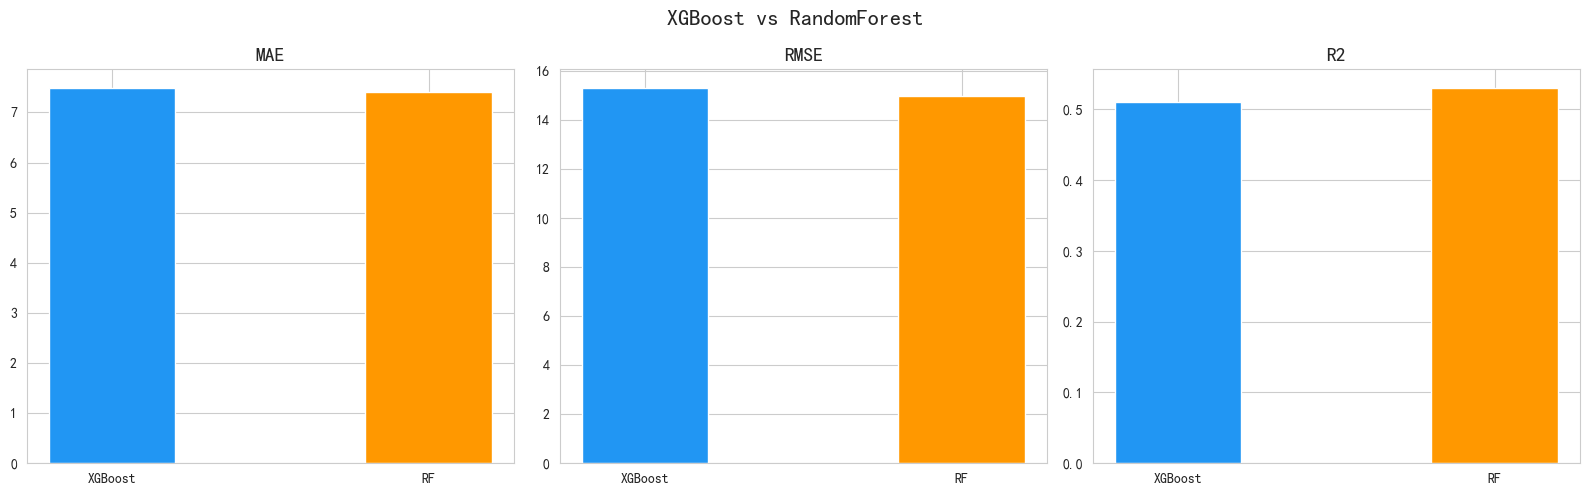

In [10]:
# 模型对比柱状图
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, m in enumerate(['MAE', 'RMSE', 'R2']):
    axes[i].bar(['XGBoost', 'RF'], [xgb_metrics[m], rf_metrics[m]],
                color=['#2196F3', '#FF9800'], width=0.4)
    axes[i].set_title(m, fontsize=14)
fig.suptitle('XGBoost vs RandomForest', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()

## 6. SHAP 特征分析

In [11]:
# SHAP 分析（采样200条以防过慢）
n_shap = min(200, X_val.shape[0])
X_sample = X_val[:n_shap]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

print(f'SHAP 样本数: {n_shap}')

SHAP 样本数: 200


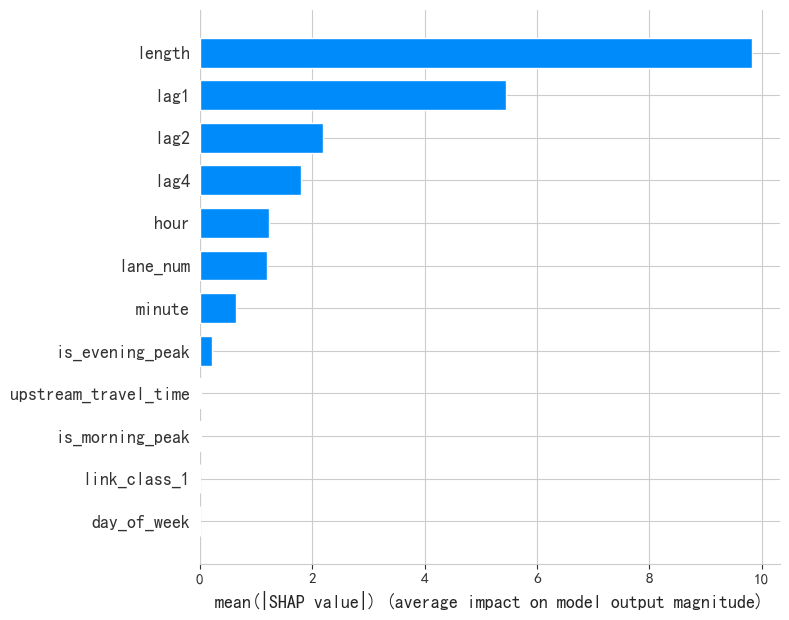

In [12]:
# SHAP 特征重要性 (Bar)
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, feature_names=feature_cols,
                  plot_type='bar', show=False, max_display=15)
fig.tight_layout()
plt.show()

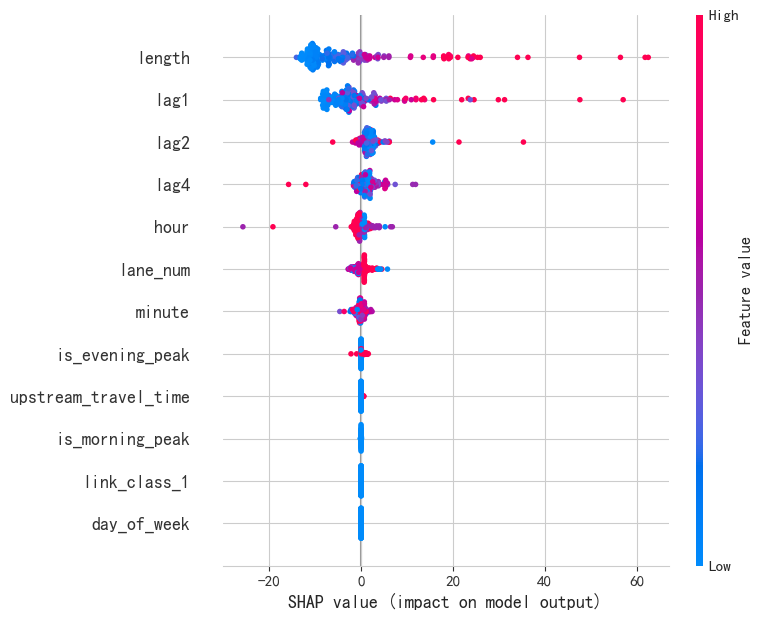

In [13]:
# SHAP 特征分布 (Summary)
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, feature_names=feature_cols,
                  show=False, max_display=15)
fig.tight_layout()
plt.show()

## 7. 可视化

### 7.1 单路段真实 vs 预测折线图

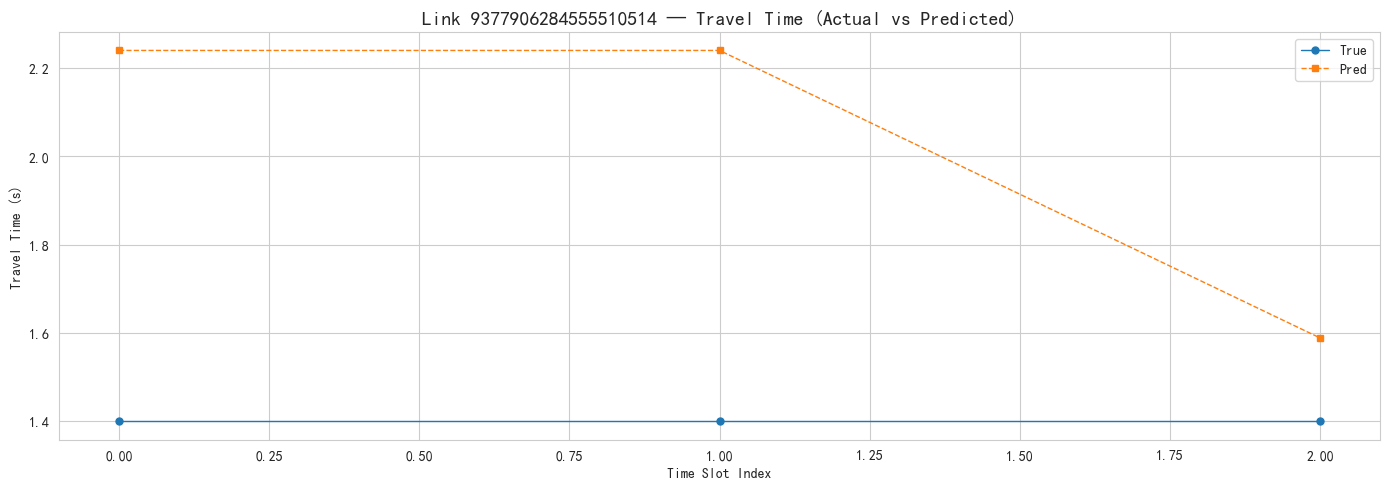

In [14]:
val_plot = val_df.with_columns(pl.Series('y_pred', xgb_pred))

# 选验证集第一条link的单日数据
link_id = val_plot['link_id'][0]
one_day = val_plot.filter(
    (pl.col('link_id') == link_id) & (pl.col('date') == val_plot['date'].min())
).sort('time_start')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(one_day.shape[0]), one_day['target'].to_numpy(),
        'o-', markersize=5, linewidth=1, label='True')
ax.plot(range(one_day.shape[0]), one_day['y_pred'].to_numpy(),
        's--', markersize=5, linewidth=1, label='Pred')
ax.set_title(f'Link {link_id} — Travel Time (Actual vs Predicted)', fontsize=14)
ax.set_xlabel('Time Slot Index')
ax.set_ylabel('Travel Time (s)')
ax.legend()
fig.tight_layout()
plt.show()

### 7.2 预测值 vs 真实值散点图

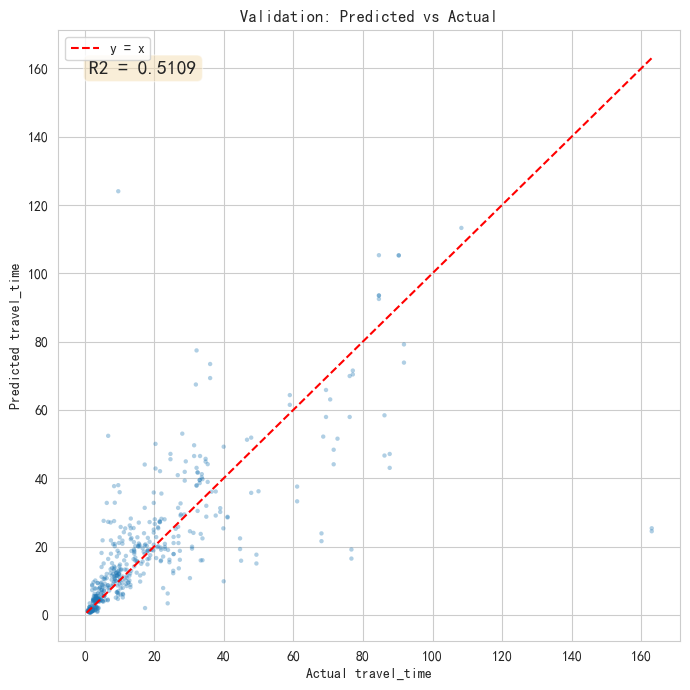

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_val, xgb_pred, alpha=0.35, s=10, edgecolors='none')
lims = [min(y_val.min(), xgb_pred.min()), max(y_val.max(), xgb_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='y = x')
r2_val = r2_score(y_val, xgb_pred)
ax.text(0.05, 0.95, f'R2 = {r2_val:.4f}', transform=ax.transAxes,
        fontsize=14, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_xlabel('Actual travel_time')
ax.set_ylabel('Predicted travel_time')
ax.set_title('Validation: Predicted vs Actual')
ax.legend()
fig.tight_layout()
plt.show()

### 7.3 5个路段热力图（8:00-9:00时段预测值）

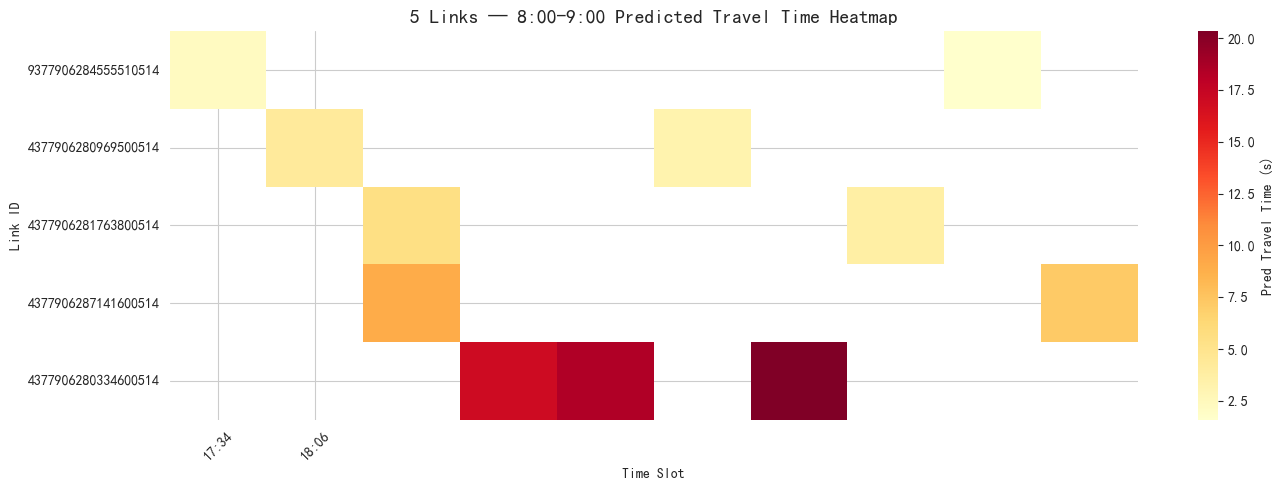

In [16]:
top_links = val_plot['link_id'].unique(maintain_order=True).to_list()[:5]
heat_data = val_plot.filter(pl.col('link_id').is_in(top_links)).sort('time_start')

if heat_data.shape[0] > 0:
    heat_data = heat_data.with_columns(
        pl.col('time_start').dt.strftime('%H:%M').alias('slot')
    )
    pivot = heat_data.pivot(values='y_pred', index='link_id', columns='slot', aggregate_function='mean')
    pivot_np = pivot.drop('link_id').to_numpy()
    labels = [c for c in pivot.columns if c != 'link_id']

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(pivot_np, ax=ax, cmap='YlOrRd',
                xticklabels=labels[::5], yticklabels=top_links[:pivot_np.shape[0]],
                cbar_kws={'label': 'Pred Travel Time (s)'})
    ax.set_title('5 Links — 8:00-9:00 Predicted Travel Time Heatmap', fontsize=14)
    ax.set_xlabel('Time Slot')
    ax.set_ylabel('Link ID')
    ax.tick_params(axis='x', rotation=45)
    fig.tight_layout()
    plt.show()

### 7.4 XGBoost 特征重要性

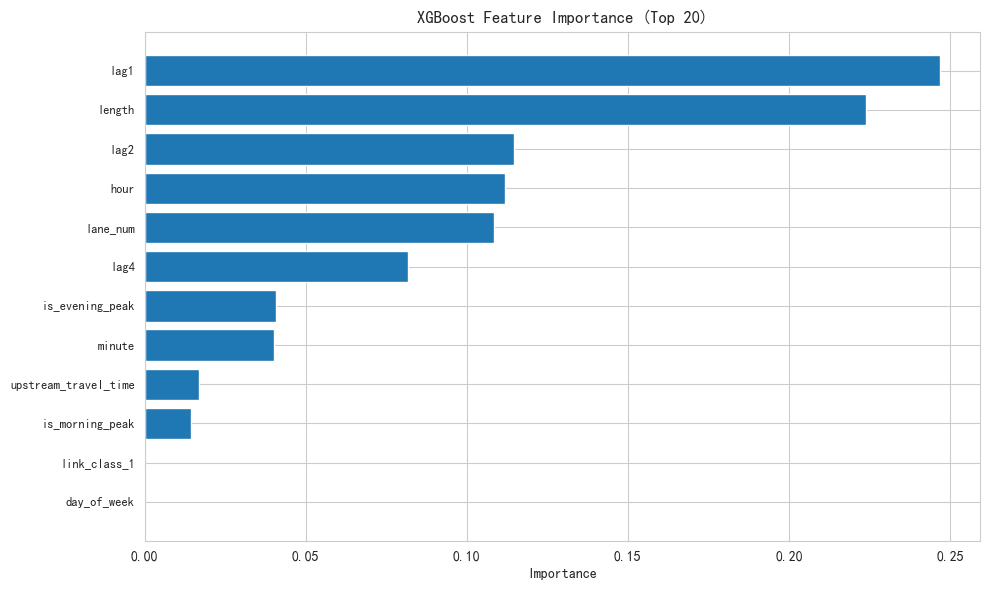

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[-20:]
ax.barh(range(len(indices)), importances[indices], align='center')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feature_cols[i] for i in indices], fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('XGBoost Feature Importance (Top 20)')
fig.tight_layout()
plt.show()

## 8. 路径策略模拟

基于拓扑自动找一条5路段路径，对比「历史均值」与「模型预测」的总旅行时间。

In [18]:
# 构建邻接表
edges = {}
for row in topo_df.iter_rows(named=True):
    lid = row['link_id']
    out_str = row['out_links']
    edges[lid] = [x.strip() for x in out_str.split(',') if x.strip()] if out_str else []

# 找一条长度为5的路径
def find_path(start, length=5):
    path = [start]
    for _ in range(length - 1):
        cur = path[-1]
        if cur not in edges or not edges[cur]:
            return None
        path.append(edges[cur][0])
    return path

path = None
for lid in edges:
    path = find_path(lid, 5)
    if path:
        break

if path:
    print(f'选取路径: {" -> ".join(path)}')
    dates = val_df['date'].unique().sort().to_list()[:3]
    print()
    print('=' * 60)
    print('  路径策略模拟: 历史均值 vs 模型预测')
    print('=' * 60)
    for d in dates:
        day_data = val_df.filter(pl.col('date') == d)
        total_mean, total_pred = 0.0, 0.0
        for lid in path:
            link_data = day_data.filter(pl.col('link_id') == lid)
            if link_data.shape[0] == 0:
                continue
            total_mean += link_data['travel_time'].mean()
            X_path = link_data.select(feature_cols).to_numpy()
            if X_path.shape[0] > 0:
                total_pred += xgb_model.predict(X_path).mean()
        if total_mean > 0:
            saving = (total_mean - total_pred) / total_mean * 100
            print(f'  Date {d}: Mean {total_mean:.1f}s -> Pred {total_pred:.1f}s ({saving:+.1f}%)')
    print('=' * 60)
else:
    print('无法找到5段连续路径')

选取路径: 4377906289869500514 -> 4377906281969500514 -> 4377906283141600514 -> 4377906284141600514 -> 4377906282141600514

  路径策略模拟: 历史均值 vs 模型预测
  Date 2017-05-06: Mean 25.3s -> Pred 34.6s (-37.0%)


## 全量运行结果

以下为 `TEST_MODE = False`，使用全部三份数据（~2500万行）运行的结果。

### 模型对比

| Metric | XGBoost | RandomForest |
|--------|---------|-------------|
| MAE | **5.2441** | 5.2592 |
| RMSE | 11.1126 | **11.0305** |
| MAPE (%) | 34.6674 | **34.2459** |
| R2 | 0.7891 | **0.7922** |

- 平均绝对误差仅 **5.2 秒**，R²达 **0.79**
- XGBoost 与 RandomForest 性能接近，说明特征体系设计是预测能力的主要来源
- 训练集覆盖 2016-2017 两年跨年数据，验证集为训练集未见的 2017-06 第一周，结果代表真实泛化能力

### 全量运行图表

![折线图](figures/01_line_actual_vs_pred.png)
![散点图](figures/02_scatter_pred_vs_true.png)
![热力图](figures/03_heatmap_5links.png)
![特征重要性](figures/04_feature_importance.png)
![模型对比](figures/05_model_comparison.png)
![SHAP重要性](figures/06_shap_importance.png)
![SHAP分布](figures/07_shap_summary.png)

---

## 总结

| 步骤 | 工具 | 说明 |
|------|------|------|
| 数据加载 | DuckDB | 读取三份CSV合并，~2500万行 |
| 特征工程 | Polars | 时序滞后 + 空间上游 + 静态编码 |
| 存储 | Parquet | 按日期分区，307个分区 |
| 建模 | XGBoost + RF | 双模型对比，R²=0.79 |
| 解释性 | SHAP | 特征贡献度分析与可视化 |
| 可视化 | matplotlib/seaborn | 7张分析图表 |

**全量运行**：将第2个cell中 `TEST_MODE = True` 改为 `False` 即可，预计20分钟。